In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension , filter_strings_by_substrings, get_scenario_dict
from utils.util import  get_dataframe_from_filepath
from utils.util import create_directory_if_not_exists
from utils.udp_util import extract_udp_prague_to_dataframe
from utils.plotter import  plot_siftr_graph

In [2]:
# Load data
mainpth="../data/udp_data_2025-04-11"
mainpth="../data/udp_data_2025-04-27"
mainpth="../data/udp_data_2025-04-28"


graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/server_data', mainpth+'/client1_data', mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '')

scenario_dict = get_scenario_dict(folderpaths)


Directory already exists: ../data/udp_data_2025-04-28\Graphs
Directory already exists: ../data/udp_data_2025-04-28\Stats
Unique Mbps and ms Combinations:
8 Mbps, 10 ms
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
Found 8Mbps_10ms in 2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
Found 8Mbps_10ms in 2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
Found 8Mbps_10ms in 3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
Found 8Mbps_10ms in 3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
Found 8Mbps_10ms in udp_prague_receiver_1_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_receiver_2_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_receiver_3_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_sender_1_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_sender_2_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_sender_3_dualpi2_8Mbps_10ms_ecn_udp.txt
F

In [3]:
for scenario in scenario_dict.keys():
    index = "1_dualpi2"

    search_list = ["1_dualpi2", "log", "txt"]
    print()
    print("Start New Scenario")
    print("Scenario", scenario)    

    my_list = scenario_dict[scenario]

    for i, item in enumerate(my_list, start=0):
        print(f"{i}. {item}")




Start New Scenario
Scenario 8Mbps_10ms
0. ../data/udp_data_2025-04-28/server_data\1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
1. ../data/udp_data_2025-04-28/server_data\1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
2. ../data/udp_data_2025-04-28/server_data\2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
3. ../data/udp_data_2025-04-28/server_data\2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
4. ../data/udp_data_2025-04-28/server_data\3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
5. ../data/udp_data_2025-04-28/server_data\3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
6. ../data/udp_data_2025-04-28/server_data\udp_prague_receiver_1_dualpi2_8Mbps_10ms_ecn_udp.txt
7. ../data/udp_data_2025-04-28/server_data\udp_prague_receiver_2_dualpi2_8Mbps_10ms_ecn_udp.txt
8. ../data/udp_data_2025-04-28/server_data\udp_prague_receiver_3_dualpi2_8Mbps_10ms_ecn_udp.txt
9. ../data/udp_data_2025-04-28/server_data\udp_prague_sender_1_dualpi2_8Mbps_10ms_ecn_udp.txt
10. ../data/udp_data_2025-04-28/server_da

2025-04-29 12:15:37,946 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-04-29 12:15:37,948 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-04-29 12:15:37,951 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-04-29 12:15:37,951 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 2.335
2025-04-29 12:15:37,952 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizTwoSymReg.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-04-29 12:15:37,953 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols


Start New Scenario
Scenario 8Mbps_10ms
['../data/udp_data_2025-04-28/client1_data\\1_dualpi2_8Mbps_10ms_ecn_udp_cubic_src1.siftr.log', '../data/udp_data_2025-04-28/client2_data\\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
['../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_8Mbps_10ms_ecn_udp.txt']
../data/udp_data_2025-04-28/client2_data\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
Cubic_UDP-Prague


2025-04-29 12:15:37,993 - DEBUG - findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\courbi.ttf', name='Courier New', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2025-04-29 12:15:37,994 - DEBUG - findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\LeelUIsl.ttf', name='Leelawadee UI', style='normal', variant='normal', weight=350, stretch='normal', size='scalable')) = 10.0975
2025-04-29 12:15:37,994 - DEBUG - findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\taile.ttf', name='Microsoft Tai Le', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-04-29 12:15:37,995 - DEBUG - findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\ARIALNBI.TTF', name='Arial', style='italic', variant='normal', weight=700, stretch='condensed', size='scalable')) = 1.535
2025-04-29 12:15:37,995 - DEBUG - findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\BOD_R.TTF', name='Bodoni MT', style='normal', variant='normal',

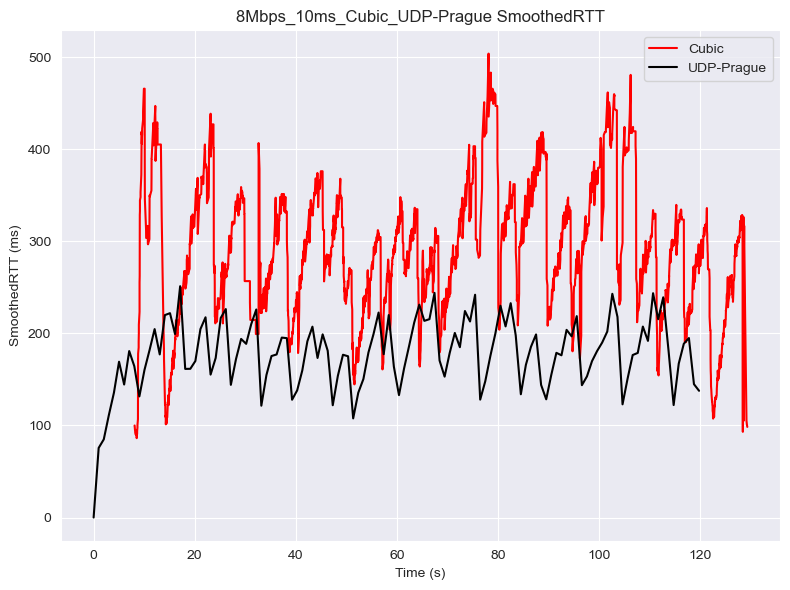

In [4]:
for scenario in scenario_dict.keys():
    index = "1_dualpi2"

    search_list_tcp = [index, "log", "src"]
    filtered_tcp = filter_strings_by_substrings(scenario_dict[scenario], search_list_tcp)

    search_list_udp = [index, "udp_prague_receiver"]
    filtered_udp = filter_strings_by_substrings(scenario_dict[scenario], search_list_udp)

    print()
    print("Start New Scenario")
    print("Scenario", scenario)
    print(filtered_tcp)
    print(filtered_udp)

    udp_traffic = filtered_udp[0]
    utf = extract_udp_prague_to_dataframe(udp_traffic)

    tcp_traffic = filtered_tcp[1]
    ttf = get_dataframe_from_filepath(tcp_traffic)
    ttf = ttf[ttf['ForeignPort'] == "5102"]

    utf.rename(columns={'RTT_ms': 'SmoothedRTT'}, inplace=True)



        # Define paths
    paths = {
        "Cubic": ttf,
        "UDP-Prague": utf
    }

    keys_string = "_".join(paths.keys())
    print(keys_string)

    scenario += str("_"+keys_string)

    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )


In [5]:
os.path.getsize(filtered_tcp[0])


17977

In [6]:
os.path.getsize(filtered_tcp[1])

3280013